# Comparación de resultados  

Con los dos modelos ya entrenados y seleccionados, el MLP de scikit-learn sobre la muestra de 1 millón de registros, y el MLP de PySpark sobre el dataset completo de aproximadamente 40 millones, esta sección consolida ambos resultados en una comparación directa. Se cargan los hiperparámetros ganadores y las métricas de evaluación de cada entorno, previamente persistidos como archivos de checkpoint, con el fin de contrastar su desempeño predictivo, su costo computacional y su comportamiento frente al desbalance de clases característico del problema de CTR.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

models_dir = "../models"

with open(os.path.join(models_dir, "mlp_sklearn_mejor_modelo_info.json")) as f:
    info_sklearn = json.load(f)

with open(os.path.join(models_dir, "mlp_pyspark_mejor_modelo_info.json")) as f:
    info_pyspark = json.load(f)

print("sklearn:", info_sklearn)
print("PySpark:", info_pyspark)

sklearn: {'iteracion': 5, 'hidden_layer_sizes': '(100, 50)', 'alpha': 0.0001, 'max_iter': 50, 'accuracy': 0.8336802289511077, 'precision': 0.5827225130890052, 'recall': 0.0657141170219047, 'f1_score': 0.11810898286199395, 'roc_auc': 0.7346225463864344, 'train_time_seg': 106.77076530456543, 'predict_time_seg': 0.4557499885559082, 'modelo_path': '../checkpoints/mlp_gridsearch\\mlp_iter5.pkl'}
PySpark: {'iteracion': 6, 'layers': '[382, 50, 2]', 'stepSize': 0.1, 'maxIter': 200, 'accuracy': 0.8328584252811813, 'precision': 0.5773647153490243, 'recall': 0.0523582444605791, 'f1_score': 0.0960098482618353, 'roc_auc': 0.7251960963996075, 'train_time_seg': 13899.288702964785, 'predict_time_seg': 21.611717224121094, 'modelo_path': '../checkpoints/pyspark\\mlp_model_iter6'}


## Tabla comparativa de métricas e hiperparámetros

Se construye una tabla que resume, lado a lado, los hiperparámetros seleccionados por cada búsqueda en grilla y las métricas de evaluación obtenidas sobre el respectivo conjunto de prueba: Accuracy, Precision, Recall, F1-score y ROC AUC, junto con los tiempos de entrenamiento y predicción de cada modelo. Dado el desbalance de clases documentado en el EDA (83% No Click / 17% Click), la lectura de esta tabla prioriza el ROC AUC y el Recall como indicadores de desempeño real, por encima del Accuracy.  

In [2]:
tabla_comparativa = pd.DataFrame([
    {
        "Entorno": "scikit-learn",
        "Hiperparámetros": f"hidden_layer_sizes={info_sklearn['hidden_layer_sizes']}, "
                            f"alpha={info_sklearn['alpha']}, max_iter={info_sklearn['max_iter']}",
        "Accuracy": info_sklearn["accuracy"],
        "Precision": info_sklearn["precision"],
        "Recall": info_sklearn["recall"],
        "F1-score": info_sklearn["f1_score"],
        "ROC AUC": info_sklearn["roc_auc"],
        "Tiempo entrenamiento (s)": info_sklearn["train_time_seg"],
        "Tiempo predicción (s)": info_sklearn["predict_time_seg"],
    },
    {
        "Entorno": "PySpark",
        "Hiperparámetros": f"layers={info_pyspark['layers']}, "
                            f"stepSize={info_pyspark['stepSize']}, maxIter={info_pyspark['maxIter']}",
        "Accuracy": info_pyspark["accuracy"],
        "Precision": info_pyspark["precision"],
        "Recall": info_pyspark["recall"],
        "F1-score": info_pyspark["f1_score"],
        "ROC AUC": info_pyspark["roc_auc"],
        "Tiempo entrenamiento (s)": info_pyspark["train_time_seg"],
        "Tiempo predicción (s)": info_pyspark["predict_time_seg"],
    },
])

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
display(tabla_comparativa)

tabla_comparativa.to_csv("../data/tabla_comparativa_sklearn_vs_pyspark.csv", index=False)


,Entorno,Hiperparámetros,Accuracy,Precision,Recall,F1-score,ROC AUC,Tiempo entrenamiento (s),Tiempo predicción (s)
0,scikit-learn,"hidden_layer_sizes=(100, 50), alpha=0.0001, ma...",0.8337,0.5827,0.0657,0.1181,0.7346,106.7708,0.4557
1,PySpark,"layers=[382, 50, 2], stepSize=0.1, maxIter=200",0.8329,0.5774,0.0524,0.0960,0.7252,13899.2887,21.6117


La tabla evidencia que ambos modelos alcanzan un desempeño global similar, con una diferencia de apenas 0.08 puntos porcentuales en Accuracy (83.37% para scikit-learn vs 83.29% para PySpark), una cercanía esperable dado que ambos modelos, al enfrentar el mismo desbalance de clases, tienden a converger hacia una predicción dominada por la clase mayoritaria. La brecha más relevante aparece en Recall (0.0657 vs 0.0524) y F1-score (0.1181 vs 0.0960), donde scikit-learn logra identificar una proporción mayor de clics reales, aunque en términos absolutos ambos valores siguen siendo bajos, confirmando que ninguno de los dos modelos resuelve satisfactoriamente el problema de la clase minoritaria sin técnicas adicionales de balanceo. La diferencia más dramática, sin embargo, está en el costo computacional: PySpark tardó 13,899.29 segundos en entrenar frente a los 106.77 segundos de scikit-learn, una diferencia de aproximadamente 130 veces, y aun así entrenó con una arquitectura de red más simple (una sola capa oculta de 50 neuronas) que la seleccionada por scikit-learn ((100, 50), dos capas). Esta comparación debe leerse con cautela: no es una comparación en igualdad de condiciones, ya que scikit-learn operó sobre una muestra de 1 millón de registros mientras que PySpark procesó el dataset completo de aproximadamente 40 millones, además de usar optimizadores distintos (Adam adaptativo vs SGD con stepSize fijo).  

## Curvas ROC comparadas

Se superponen las curvas ROC de ambos modelos sobre un mismo gráfico, junto con la diagonal de referencia correspondiente a un clasificador aleatorio (AUC = 0.5). Esta visualización permite evaluar de forma directa la capacidad de cada modelo para discriminar entre impresiones con clic y sin clic a lo largo de todos los posibles umbrales de decisión, complementando el valor puntual de ROC AUC reportado en la tabla anterior.

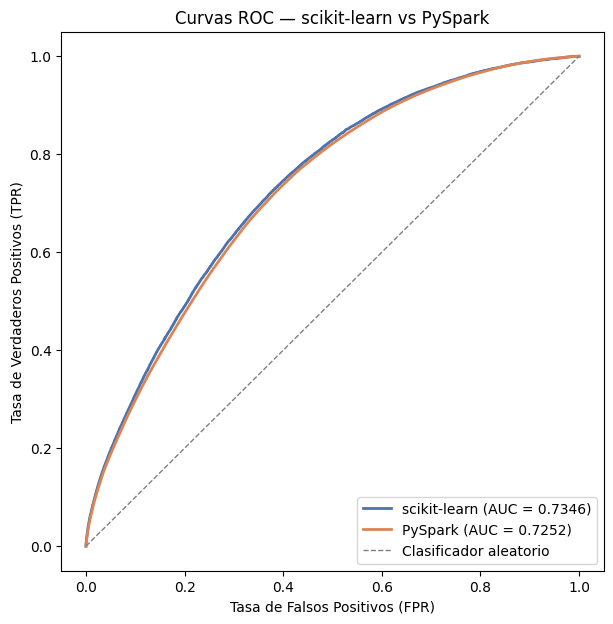

In [3]:
roc_sklearn = np.load("../models/roc_curve_sklearn.npz")
roc_pyspark = np.load("../models/roc_curve_pyspark.npz")

plt.figure(figsize=(7, 7))
plt.plot(roc_sklearn["fpr"], roc_sklearn["tpr"],
         color="#4C72B0", lw=2, label=f"scikit-learn (AUC = {float(roc_sklearn['auc']):.4f})")
plt.plot(roc_pyspark["fpr"], roc_pyspark["tpr"],
         color="#DD8452", lw=2, label=f"PySpark (AUC = {float(roc_pyspark['auc']):.4f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Clasificador aleatorio")

plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curvas ROC — scikit-learn vs PySpark")
plt.legend(loc="lower right")
plt.savefig("../data/roc_comparacion.png", dpi=150, bbox_inches="tight")
plt.show()

Ambas curvas se ubican claramente por encima de la diagonal de referencia, confirmando que los dos modelos superan a un clasificador aleatorio, aunque con una capacidad de discriminación moderada más que sobresaliente. La curva de scikit-learn se mantiene consistentemente por encima de la de PySpark a lo largo de la mayoría de los umbrales, lo que se traduce en el AUC superior ya reportado (0.7346 vs 0.7252). La separación entre ambas curvas es visible pero no dramática, lo que sugiere que la diferencia de desempeño entre los dos entornos responde más a decisiones de diseño del experimento (tamaño de muestra, arquitectura, optimizador) que a una limitación estructural del algoritmo MLP en sí. Ninguna de las dos curvas se acerca a la esquina superior izquierda (el comportamiento ideal), lo cual es consistente con el Recall bajo observado en ambos modelos: la red logra ordenar razonablemente bien las probabilidades relativas entre clases, pero no logra separarlas con la contundencia necesaria para una clasificación binaria de alta confianza en el umbral estándar de 0.5.

## Comparación de tiempos de cómputo

Se grafican, en paneles separados, los tiempos de entrenamiento y de predicción de cada entorno. El objetivo es visualizar la magnitud de la diferencia de costo computacional entre un enfoque de cómputo en un solo nodo (scikit-learn, sobre una muestra reducida) frente a un enfoque de cómputo distribuido (PySpark, sobre el dataset completo), insumo clave para la reflexión sobre cuándo se justifica el uso de cada herramienta.

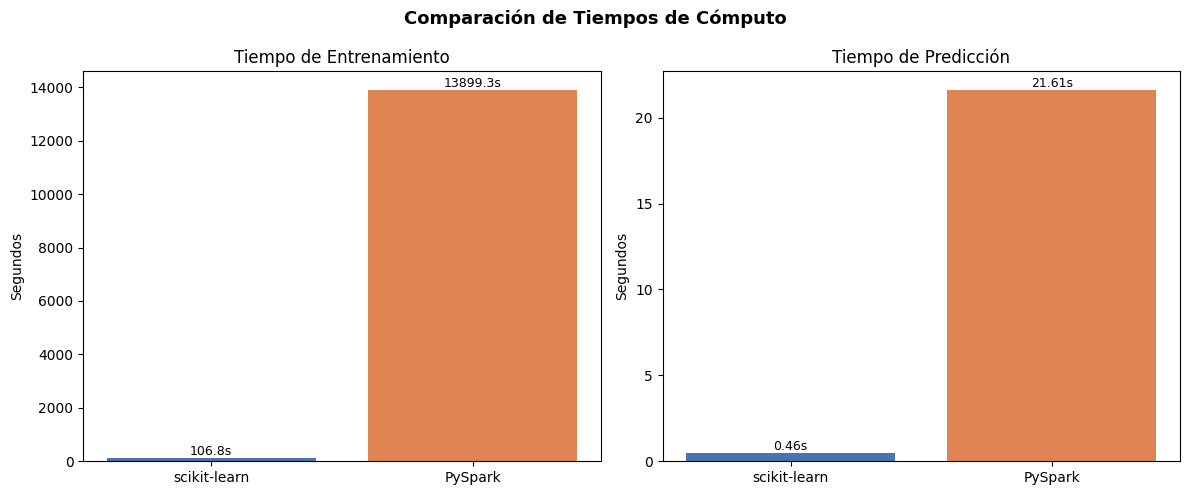

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

entornos = ["scikit-learn", "PySpark"]
colores = ["#4C72B0", "#DD8452"]

tiempos_train = [info_sklearn["train_time_seg"], info_pyspark["train_time_seg"]]
tiempos_predict = [info_sklearn["predict_time_seg"], info_pyspark["predict_time_seg"]]

axes[0].bar(entornos, tiempos_train, color=colores)
axes[0].set_title("Tiempo de Entrenamiento")
axes[0].set_ylabel("Segundos")
for i, v in enumerate(tiempos_train):
    axes[0].text(i, v, f"{v:.1f}s", ha="center", va="bottom", fontsize=9)

axes[1].bar(entornos, tiempos_predict, color=colores)
axes[1].set_title("Tiempo de Predicción")
axes[1].set_ylabel("Segundos")
for i, v in enumerate(tiempos_predict):
    axes[1].text(i, v, f"{v:.2f}s", ha="center", va="bottom", fontsize=9)

plt.suptitle("Comparación de Tiempos de Cómputo", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/tiempos_comparacion.png", dpi=150, bbox_inches="tight")
plt.show()

El gráfico de tiempos deja en evidencia la asimetría más marcada de toda la comparación. En entrenamiento, PySpark requirió casi 3.86 horas frente a menos de dos minutos de scikit-learn, una diferencia que no se explica únicamente por el volumen de datos (40 veces más registros), sino también por el overhead inherente al cómputo distribuido: coordinación de tareas entre particiones, shuffles de datos y comunicación entre el driver y los executors, costos que no existen en un entrenamiento de un solo proceso. En predicción la brecha se reduce en términos relativos, pero PySpark sigue siendo aproximadamente 47 veces más lento (21.61s vs 0.46s). Esto sugiere que, en la configuración local de un solo nodo usada en este proyecto, PySpark no logra aprovechar su ventaja teórica de paralelismo distribuido, ya que todos los "executors" compiten por los mismos núcleos de CPU de una sola máquina en lugar de operar en hardware físicamente separado. A esto se suma una restricción práctica de la máquina utilizada: aunque el procesador cuenta con 16 núcleos disponibles, la SparkSession se configuró con `local[6]` en lugar de `local[16]`, ya que con más núcleos activos el consumo de memoria RAM (32 GB DDR5) se convertía en el verdadero cuello de botella. Cada núcleo adicional implica una partición más procesándose en paralelo, y con un vector de features de 382 dimensiones (mayormente denso tras el One-Hot Encoding) sobre un dataset de aproximadamente 40 millones de registros, forzar más paralelismo del que la memoria disponible podía sostener derivaba en swapping a disco y ralentización general, en lugar de una aceleración real.   

Este es un ejemplo concreto de que el paralelismo de Spark no es gratuito: cada executor adicional necesita su propia porción de memoria para almacenar particiones, estructuras intermedias y el estado del modelo durante el entrenamiento, por lo que el verdadero factor limitante en una máquina de un solo nodo termina siendo la relación entre núcleos disponibles y memoria por núcleo, no solo el conteo de núcleos en sí. Este resultado es clave para la reflexión de cuándo conviene usar cada herramienta: el costo de la infraestructura distribuida solo se justifica cuando el volumen de datos hace inviable el entrenamiento en un solo nodo *y* se cuenta con memoria suficiente para sostener el paralelismo deseado, en un clúster real, este cuello de botella se resolvería distribuyendo la memoria entre varias máquinas físicas en lugar de comprimirla en un único equipo de 32 GB.


## Comparación de métricas de clasificación

Se presentan, mediante un gráfico de barras agrupadas, las cinco métricas de evaluación de ambos modelos una junto a la otra. Esta representación visual facilita identificar en qué métricas específicas un entorno superó al otro, y en qué magnitud, más allá de la lectura numérica de la tabla comparativa.

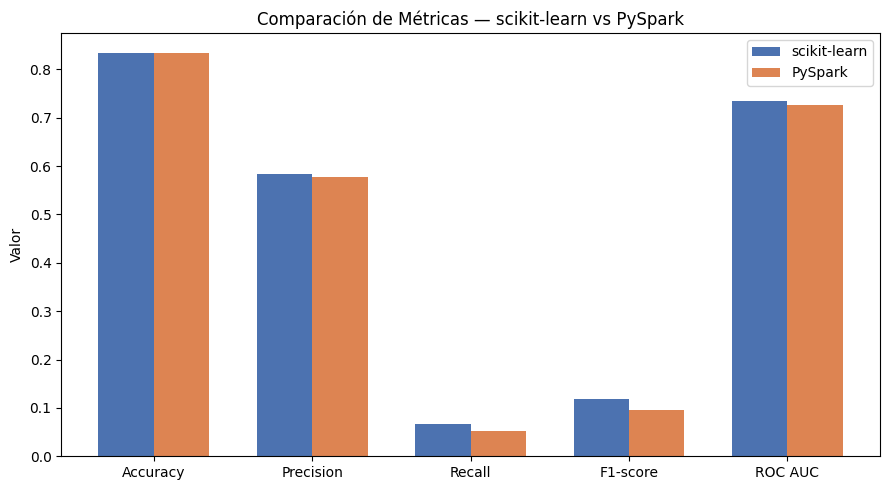

In [5]:
metricas = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]
etiquetas = ["Accuracy", "Precision", "Recall", "F1-score", "ROC AUC"]

valores_sklearn = [info_sklearn[m] for m in metricas]
valores_pyspark = [info_pyspark[m] for m in metricas]

x = np.arange(len(metricas))
ancho = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - ancho/2, valores_sklearn, ancho, label="scikit-learn", color="#4C72B0")
ax.bar(x + ancho/2, valores_pyspark, ancho, label="PySpark", color="#DD8452")

ax.set_xticks(x)
ax.set_xticklabels(etiquetas)
ax.set_ylabel("Valor")
ax.set_title("Comparación de Métricas — scikit-learn vs PySpark")
ax.legend()
plt.tight_layout()
plt.savefig("../data/metricas_comparacion.png", dpi=150, bbox_inches="tight")
plt.show()

El gráfico de barras agrupadas confirma visualmente lo señalado en la tabla: Accuracy es prácticamente indistinguible entre ambos entornos, la barra más alta y más engañosa de las cinco, dado el desbalance de clases, mientras que Precision se mantiene cercana entre ambos modelos (0.58 vs 0.58). Las diferencias más visibles se concentran en Recall y F1-score, donde las barras de scikit-learn superan consistentemente a las de PySpark, aunque ambas permanecen muy por debajo de 0.15 en una escala de 0 a 1. ROC AUC muestra la brecha más moderada de las métricas "de calidad" (0.73 vs 0.73), reforzando la idea de que ambos modelos tienen una capacidad de discriminación similar, y que la ventaja de scikit-learn se concentra específicamente en su capacidad de identificar correctamente la clase minoritaria (clics) una vez fijado el umbral de decisión estándar. En conjunto, el gráfico refuerza que ninguna métrica muestra una diferencia dramática de calidad entre los dos entornos, la elección entre uno y otro, en este proyecto, se decide más por el costo computacional que por la precisión obtenida.

# Reflexión Final  

## ¿Qué entorno fue más rápido?

Scikit-learn, por un margen enorme. Entrenó en 106.77 segundos frente a los 13,899.29 segundos (≈3.86 horas) de PySpark — una diferencia de ~130x. En predicción la brecha se achica pero sigue siendo grande: 0.46s en sklearn vs 21.61s en PySpark (~47x). Esto no es sorprendente dado el contexto: sklearn entrenó sobre la muestra de 1M de registros en un solo nodo con paralelismo interno mínimo pero sin overhead de coordinación, mientras que PySpark procesó el dataset completo (~40M filas) y además paga un costo fijo de orquestación distribuida (planificación de tareas, shuffles, serialización JVM↔Python) que domina el tiempo total cuando, como en tu caso, todo corre en una sola máquina (local[6]) en vez de un clúster real. En un clúster con varios nodos físicos, esa brecha se reduciría porque el paralelismo dejaría de ser "simulado" en los mismos núcleos.  

## ¿Cuál fue más preciso?

Scikit-learn, aunque por un margen modesto: ROC AUC de 0.7346 vs 0.7252 de PySpark, con Accuracy prácticamente empatada (0.8337 vs 0.8329 — recuerda que esta métrica es poco informativa aquí por el desbalance de clases). La diferencia más relevante está en Recall: 0.0657 en sklearn vs 0.0524 en PySpark, es decir, sklearn detecta proporcionalmente más clics reales, aunque ambos valores son bajos en términos absolutos. Vale la pena matizar esta comparación: no es enteramente "manzanas con manzanas" — sklearn entrenó sobre 1M de registros muestreados y PySpark sobre los ~40M completos, con arquitecturas de red distintas ((100,50) vs [382,50,2]) y hiperparámetros de optimización distintos (Adam adaptativo por defecto en sklearn vs SGD con stepSize fijo en PySpark). La diferencia de desempeño probablemente responde más a esas decisiones de diseño que a una superioridad intrínseca de un framework sobre otro.

## ¿Cuándo es útil PySpark?

No cuando el dataset cabe cómodamente en la RAM de una sola máquina, como demuestran tus propios tiempos: ahí scikit-learn gana claramente en velocidad y comodidad de desarrollo (arrays de NumPy nativos, LIME funciona sin fricciones, no hay overhead de JVM). PySpark se vuelve indispensable cuando el volumen de datos excede la memoria disponible en un solo nodo — el caso real del dataset completo de Avazu (~40M filas, varios GB), que sencillamente no cabría en un DataFrame de pandas sin hacer sampling. Su ventaja real emerge en un clúster con varios nodos físicos (no en local[6] sobre una sola laptop, que es donde corriste tú), donde el procesamiento se reparte de verdad en paralelo entre máquinas distintas en vez de competir por los mismos núcleos. También es la opción natural cuando el pipeline de datos ya vive en un ecosistema Spark (Hadoop, Databricks, data lakes), evitando mover los datos fuera de ese entorno solo para entrenar el modelo.

## ¿Qué aporta LIME?

Abre la caja negra del MLP a nivel de instancia individual, algo que las métricas agregadas (Accuracy, F1, ROC AUC) no pueden mostrar. En tus dos casos analizados —un falso negativo y un falso positivo— LIME reveló que el modelo se apoya principalmente en variables de contexto (site_domain, app_domain, app_category, site_category, app_id) para decidir, y que sus errores no son arbitrarios: en el falso negativo, el modelo sí "sentía" la dirección correcta (probabilidad empujada hacia Click) pero sin fuerza suficiente para cruzar el umbral de 0.5; en el falso positivo, ocurrió lo simétrico. Esto aporta dos cosas prácticas: primero, confianza de que el modelo usa señales razonables del dominio del problema y no patrones espurios; segundo, diagnóstico de calibración — el problema no parece ser que el modelo "mire" las variables equivocadas, sino que le cuesta calibrar la magnitud de su confianza cerca del umbral de decisión, lo cual es un hallazgo accionable (sugiere explorar ajuste de umbral o recalibración de probabilidades, más que rediseñar por completo la arquitectura).